<a href="https://colab.research.google.com/github/NathanEsser/ilhas-de-calor-blumenau/blob/main/ilhas_de_calor_blumenau.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
!pip install -q geobr

In [21]:
import ee, geemap, geobr
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from google.colab import drive
drive.mount('/content/drive')

PASTA = Path('/content/drive/MyDrive/ilhas-de-calor-blumenau/dados')
PASTA.mkdir(parents=True, exist_ok=True)

def checar(condicao, mensagem):
    """Mostra ✅ se a condição for verdadeira, ⚠️ se não for."""
    print(f"{'✅ OK' if condicao else '⚠️ ALERTA'}: {mensagem}")
    return condicao

Mounted at /content/drive


In [22]:
PROJETO_EE = 'ilhas-calor-blumenau'  #Variável do nome do projeto criado no Google Earth Engine

ee.Authenticate() #Login na plataforma do Google Earth
ee.Initialize(project=PROJETO_EE) #Informa em qual projeto vamos atuar
print("Earth Engine inicializado no projeto:", PROJETO_EE)

Earth Engine inicializado no projeto: ilhas-calor-blumenau


In [23]:
ponto_blumenau = ee.Geometry.Point([-49.066, -26.919])  # [longitude, latitude]

n_l9 = (ee.ImageCollection('LANDSAT/LC09/C02/T1_L2')
        .filterBounds(ponto_blumenau)
        .size()
        .getInfo())

print("Imagens Landsat 9 sobre Blumenau:", n_l9)
checar(n_l9 > 0, "Earth Engine responde e encontra imagens Landsat 9 sobre Blumenau")

Imagens Landsat 9 sobre Blumenau: 85
✅ OK: Earth Engine responde e encontra imagens Landsat 9 sobre Blumenau


True

In [24]:
COD_BLUMENAU = 4202404 #4202404 é o código IBGE de Blumenau. O 42 no início é o código de Santa Catarina.

municipio = geobr.read_municipality(code_muni=COD_BLUMENAU, year=2022, simplified=False)

# 2. Bairros, com plano B: 2022 → 2010 → setores censitários
def baixar_areas():
    for ano in [2022, 2010]:
        try:
            b = geobr.read_neighborhood(year=ano, simplified=False)
            b = b[b['code_muni'].astype(int) == COD_BLUMENAU]
            if len(b) > 0:
                return b, f'bairros IBGE {ano}'
            print(f'Bairros {ano}: base existe, mas não tem Blumenau')
        except Exception as e:
            print(f'Bairros {ano} indisponíveis: {e}')
    for ano in [2022, 2010]:
        try:
            s = geobr.read_census_tract(code_tract=COD_BLUMENAU, year=ano, simplified=False)
            if len(s) > 0:
                return s, f'setores censitários {ano}'
        except Exception as e:
            print(f'Setores {ano} indisponíveis: {e}')
    raise RuntimeError('Nenhuma base de áreas encontrada para Blumenau')

areas, FONTE_AREAS = baixar_areas()
print('Fonte usada:', FONTE_AREAS)
print('Colunas disponíveis:', list(areas.columns))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Fonte usada: bairros IBGE 2022
Colunas disponíveis: ['code_muni', 'name_muni', 'code_neighborhood', 'name_neighborhood', 'code_district', 'name_district', 'code_subdistrict', 'name_subdistrict', 'code_state', 'abbrev_state', 'name_state', 'code_region', 'name_region', 'year', 'geometry']


In [25]:
# 3. Padroniza o nome da área (usa a primeira coluna de nome que existir)
candidatas = ['name_neighborhood', 'name_neighbo', 'name_district', 'code_tract']
coluna_nome = next(c for c in candidatas if c in areas.columns)
print('Coluna usada como nome:', coluna_nome)

areas = areas.copy()
areas['nome_area'] = areas[coluna_nome].astype(str).str.strip()
areas = areas[['nome_area', 'geometry']].reset_index(drop=True)

# 4. Salva tudo num único arquivo GeoPackage, com duas camadas
ARQ_AREAS = PASTA / 'area_estudo.gpkg'
municipio.to_file(ARQ_AREAS, layer='municipio', driver='GPKG')
areas.to_file(ARQ_AREAS, layer='areas', driver='GPKG')
print('Salvo em:', ARQ_AREAS)

Coluna usada como nome: name_neighborhood
Salvo em: /content/drive/MyDrive/ilhas-de-calor-blumenau/dados/area_estudo.gpkg


In [26]:
# Compreendendo a tablea gemotry - Basicamente retorna uma sequência de coordenadas dos bairros de blumenau, que quando ligados, formam o "desenho/polígono" de cada bairro
print(areas.head(3))

# O polígono do primeiro bairro, escrito como texto (só os primeiros caracteres)
print(areas['nome_area'].iloc[0])
print(areas.geometry.iloc[0].wkt[:300])

# Quantos pontos (vértices) formam todos os 35 bairros juntos
import shapely
print('Total de vértices:', shapely.get_num_coordinates(areas.geometry).sum())

         nome_area                                           geometry
0           Centro  MULTIPOLYGON (((-49.06556 -26.9245, -49.06582 ...
1         Vorstadt  MULTIPOLYGON (((-49.04962 -26.9207, -49.05133 ...
2  Ribeirão Fresco  MULTIPOLYGON (((-49.03652 -26.93104, -49.03659...
Centro
MULTIPOLYGON (((-49.065565 -26.924500499999997, -49.0658161 -26.9244471, -49.0659621 -26.924375, -49.0665212 -26.924190499999998, -49.0668429 -26.9241231, -49.0669567 -26.9241154, -49.06704949999999 -26.9241329, -49.0671598 -26.924187699999997, -49.067473799999995 -26.924270699999994, -49.0675646000
Total de vértices: 26577


Área do município: 518.7 km² (IBGE: ≈ 518,6)
Área coberta pelas 35 áreas: 207.5 km²


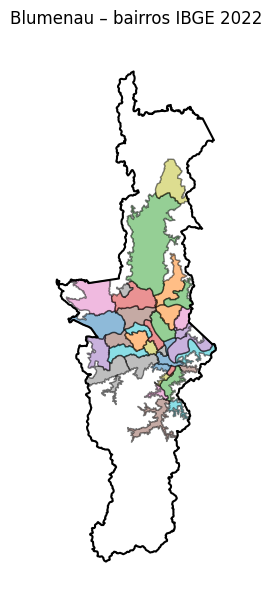

In [27]:
#Construção do mapa da cidade e da divisão dos bairros.
UTM = 31982  # SIRGAS 2000 / UTM 22S, em metros

area_mun_km2 = municipio.to_crs(UTM).area.sum() / 1e6
area_areas_km2 = areas.to_crs(UTM).area.sum() / 1e6
print(f'Área do município: {area_mun_km2:.1f} km² (IBGE: ≈ 518,6)')
print(f'Área coberta pelas {len(areas)} áreas: {area_areas_km2:.1f} km²')

# Checagem visual: os bairros devem ficar dentro do contorno do município
ax = municipio.to_crs(UTM).boundary.plot(color='black', figsize=(7, 7))
areas.to_crs(UTM).plot(ax=ax, column='nome_area', alpha=0.5, edgecolor='black')
ax.set_title(f'Blumenau – {FONTE_AREAS}')
ax.set_axis_off()

Centro - 376 pontos
Primeiro ponto: (692075.0208639164, 7020458.38109014)
Último ponto:   (692075.0208639164, 7020458.38109014)


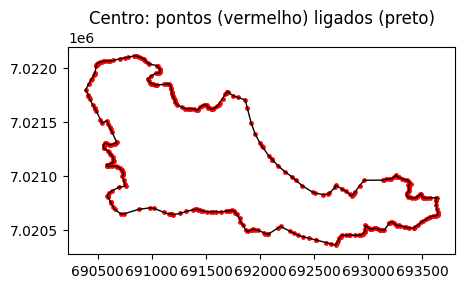

In [28]:
# Compreendendo como que funciona o desenho.
# Separa bairros com vários pedaços em polígonos individuais e pega o primeiro
bairro = areas.to_crs(UTM).explode(index_parts=False).iloc[0]

# .exterior = contorno externo; .xy = listas de coordenadas X e Y dos vértices
x, y = bairro.geometry.exterior.xy
print(bairro['nome_area'], '-', len(x), 'pontos')
print('Primeiro ponto:', (x[0], y[0]))
print('Último ponto:  ', (x[-1], y[-1]))   # Verfiicar se é igual ao primeiro: o polígono fecha

plt.figure(figsize=(5, 5))
plt.plot(x, y, color='black', linewidth=1)    # liga os pontos em ordem
plt.scatter(x, y, s=6, color='red')           # mostra os pontos em si
plt.gca().set_aspect('equal')                 # mesma escala em X e Y, sem distorcer
plt.title(f"{bairro['nome_area']}: pontos (vermelho) ligados (preto)")
plt.show()

In [29]:
# Parte 4 · Faça
VERAO_INICIO = '2022-12-01'
VERAO_FIM    = '2026-04-01'   # a data final não entra: vai até 31/03/2026
NUVEM_MAX    = 60

# Simplifica o contorno em metros (UTM) e volta para graus (EPSG:4326)
mun_leve = municipio[['geometry']].to_crs(UTM)
mun_leve['geometry'] = mun_leve.geometry.simplify(10)
mun_leve = mun_leve.to_crs(epsg=4326)
print('Vértices antes:', shapely.get_num_coordinates(municipio.geometry).sum(),
      '| depois:', shapely.get_num_coordinates(mun_leve.geometry).sum())

area_ee = geemap.gdf_to_ee(mun_leve)
regiao = area_ee.geometry()

#Criada uma função porque vamos aplicar exatamente os mesmos filtros a dois satélites. Assim, as regras são escritas uma vez só.
# filterBounds(regiao)	Só fotos que cobrem Blumenau
# filterDate(...)	Só fotos de dez/2022 a mar/2026
# calendarRange(12, 3, 'month')	Só fotos de dez, jan, fev e mar (tira os invernos do meio)
# lt('CLOUD_COVER', 60)	Só fotos com menos de 60% de nuvem (lt = less than, menor que)
def filtrar(colecao_id):
    return (ee.ImageCollection(colecao_id)
            .filterBounds(regiao)
            .filterDate(VERAO_INICIO, VERAO_FIM)
            .filter(ee.Filter.calendarRange(12, 3, 'month'))
            .filter(ee.Filter.lt('CLOUD_COVER', NUVEM_MAX)))

l8 = filtrar('LANDSAT/LC08/C02/T1_L2')
l9 = filtrar('LANDSAT/LC09/C02/T1_L2')
imagens = l8.merge(l9).sort('system:time_start')

# print(imagens)   # ainda é só uma instrução: nada foi calculado

Vértices antes: 10170 | depois: 1538


In [30]:
# Parte 4 · Valide
import pandas as pd

props = ee.Dictionary({
    'data':     imagens.aggregate_array('DATE_ACQUIRED'),
    'satelite': imagens.aggregate_array('SPACECRAFT_ID'),
    'nuvem':    imagens.aggregate_array('CLOUD_COVER'),
}).getInfo()   # aqui o Earth Engine calcula de verdade

df = pd.DataFrame(props)
df['data'] = pd.to_datetime(df['data'])
df['mes'] = df['data'].dt.month

# Dezembro pertence ao verão do ano seguinte (dez/2022 → verão 2022/23)
def verao(d):
    ano = d.year if d.month == 12 else d.year - 1
    return f"{ano}/{str(ano + 1)[-2:]}"
df['verao'] = df['data'].apply(verao)

print(df.groupby(['verao', 'satelite']).size().unstack(fill_value=0))
print(f"\nTotal: {len(df)} imagens")

checar(len(df) >= 5, f"{len(df)} imagens (mínimo: 5)")
checar(df['mes'].isin([12, 1, 2, 3]).all(), "todas as imagens são de dezembro a março")
checar(df['nuvem'].max() < NUVEM_MAX, "nenhuma cena acima de 60% de nuvem")
checar(df['satelite'].nunique() == 2, "Landsat 8 e 9 presentes")

satelite  LANDSAT_8  LANDSAT_9
verao                         
2022/23           6          7
2023/24          10          8
2024/25           5          9
2025/26          10          9

Total: 64 imagens
✅ OK: 64 imagens (mínimo: 5)
✅ OK: todas as imagens são de dezembro a março
✅ OK: nenhuma cena acima de 60% de nuvem
✅ OK: Landsat 8 e 9 presentes


True

In [31]:
# Parte 5 · Aquecimento: lendo bits da QA_PIXEL
for valor in [21824, 22280]:
    print(valor, '→', format(valor, '016b'),
          '| bit 1:', (valor >> 1) & 1,
          '| bit 3:', (valor >> 3) & 1,
          '| bit 4:', (valor >> 4) & 1)

21824 → 0101010101000000 | bit 1: 0 | bit 3: 0 | bit 4: 0
22280 → 0101011100001000 | bit 1: 0 | bit 3: 1 | bit 4: 0


In [32]:
# Parte 5 · Faça
def remover_nuvens(img):
    """Apaga (mascara) pixels de nuvem, borda de nuvem e sombra."""
    qa = img.select('QA_PIXEL')
    nuvem = (qa.bitwiseAnd(1 << 1).neq(0)          # bit 1: nuvem dilatada (borda)
             .Or(qa.bitwiseAnd(1 << 3).neq(0))     # bit 3: nuvem
             .Or(qa.bitwiseAnd(1 << 4).neq(0)))    # bit 4: sombra de nuvem
    return img.updateMask(nuvem.Not())             # mantém só onde NÃO é nuvem

def converter(img):
    """Transforma números brutos em temperatura (°C) e NDVI."""
    temp_c = (img.select('ST_B10')
                 .multiply(0.00341802).add(149.0)  # → Kelvin
                 .subtract(273.15)                 # → °C
                 .rename('temp_c'))
    refl = img.select(['SR_B4', 'SR_B5']).multiply(0.0000275).add(-0.2)  # → reflectância
    ndvi = refl.normalizedDifference(['SR_B5', 'SR_B4']).rename('ndvi')   # (B5−B4)/(B5+B4)
    return img.addBands(temp_c).addBands(ndvi).select(['temp_c', 'ndvi'])

Teste de dados em uma única imagem

In [33]:
# Parte 5 · Teste em uma imagem
teste_bruta = imagens.sort('CLOUD_COVER').first()
teste = converter(remover_nuvens(teste_bruta))

info = ee.Dictionary({
    'data':       teste_bruta.get('DATE_ACQUIRED'),
    'satelite':   teste_bruta.get('SPACECRAFT_ID'),
    'nuvem_cena': teste_bruta.get('CLOUD_COVER'),
}).getInfo()
print('Imagem de teste:', info)

Imagem de teste: {'data': '2023-03-20', 'nuvem_cena': 0.53, 'satelite': 'LANDSAT_9'}


In [34]:
# Parte 5 · Valide
redutor = ee.Reducer.percentile([5, 50, 95]).combine(ee.Reducer.minMax(), sharedInputs=True)

stats = teste.reduceRegion(reducer=redutor, geometry=regiao,
                           scale=30, maxPixels=1e9).getInfo()

# Fração de Blumenau com dado válido nesta imagem (0 a 1)
validos = (teste.select('temp_c').mask()
           .reduceRegion(ee.Reducer.mean(), regiao, 30, maxPixels=1e9)
           .get('temp_c').getInfo())

print(f"Temperatura (°C): mín {stats['temp_c_min']:.1f} | p5 {stats['temp_c_p5']:.1f} | "
      f"mediana {stats['temp_c_p50']:.1f} | p95 {stats['temp_c_p95']:.1f} | máx {stats['temp_c_max']:.1f}")
print(f"NDVI:             mín {stats['ndvi_min']:.2f} | p5 {stats['ndvi_p5']:.2f} | "
      f"mediana {stats['ndvi_p50']:.2f} | p95 {stats['ndvi_p95']:.2f} | máx {stats['ndvi_max']:.2f}")
print(f"Área com dado válido: {validos:.0%}")

checar(15 <= stats['temp_c_p50'] <= 50, f"mediana da temperatura {stats['temp_c_p50']:.1f} °C (faixa 15–50)")
checar(stats['ndvi_min'] >= -1 and stats['ndvi_max'] <= 1, "NDVI entre −1 e 1")

Temperatura (°C): mín 25.4 | p5 29.4 | mediana 32.9 | p95 40.9 | máx 64.2
NDVI:             mín -0.95 | p5 0.35 | mediana 0.89 | p95 0.91 | máx 1.00
Área com dado válido: 100%
✅ OK: mediana da temperatura 32.9 °C (faixa 15–50)
✅ OK: NDVI entre −1 e 1


True

Lendo o resultado

Temperatura: mediana de 32,9 °C, dentro da faixa. A distribuição faz sentido: metade de Blumenau entre ~29 e ~41 °C (p5 a p95) numa manhã de verão.

Mínimo de 25,4 °C:Se uma nuvem tivesse escapado da máscara, apareceria um mínimo absurdo, perto de 0 °C ou negativo. O pixel mais frio estar em 25 °C, provavelmente rio ou mata densa, indica que nesta imagem a máscara funcionou. Com uma ressalva honesta: escolhemos a imagem com menos nuvem, então foi o teste mais fácil. A prova de fogo é o mapa da Parte 6, com todas as 64.

Máximo de 64,2 °C: Telhados metálicos e galpões industriais escuros chegam a temperaturas assim sob sol forte. O código demonstra a temperatura do material, não do ar. Como o p95 está em 40,9 °C, são pouquíssimos pixels.

NDVI: mediana de 0,89, confirmando que a maior parte do município é mata densa (≥ 0,6). O mínimo de −0,95 é água (o Itajaí-Açu).

NDVI máximo = 1,00 em poucos pixels, provável efeito de sombra de relevo; não afeta medianas.

In [36]:
# Parte 6 · Faça (1/2): composição
colecao = imagens.map(remover_nuvens).map(converter)

composta = colecao.median().clip(regiao)                               # verão típico
n_obs = colecao.select('temp_c').count().rename('n_obs').clip(regiao)  # nº de valores válidos por pixel

# Bairros simplificados (mesma lógica do município) para desenhar no mapa e usar na Parte 7
bairros_leve = areas.to_crs(UTM)
bairros_leve['geometry'] = bairros_leve.geometry.simplify(10)
bairros_ee = geemap.gdf_to_ee(bairros_leve.to_crs(epsg=4326))

In [37]:
# Parte 6 · Valide
redutor = ee.Reducer.percentile([5, 50, 95]).combine(ee.Reducer.minMax(), sharedInputs=True)
stats6 = (composta.addBands(n_obs)
          .reduceRegion(reducer=redutor, geometry=regiao, scale=30, maxPixels=1e9)
          .getInfo())

p5, p50, p95 = stats6['temp_c_p5'], stats6['temp_c_p50'], stats6['temp_c_p95']
amplitude = p95 - p5

print(f"Temperatura (°C): mín {stats6['temp_c_min']:.1f} | p5 {p5:.1f} | mediana {p50:.1f} | "
      f"p95 {p95:.1f} | máx {stats6['temp_c_max']:.1f}")
print(f"NDVI mediano: {stats6['ndvi_p50']:.2f}")
print(f"Observações limpas por pixel: mín {stats6['n_obs_min']:.0f} | "
      f"mediana {stats6['n_obs_p50']:.0f} | máx {stats6['n_obs_max']:.0f}")

checar(p5 < p50 < p95, "percentis em ordem (p5 < p50 < p95)")
checar(3 <= amplitude <= 25, f"amplitude p5–p95 de {amplitude:.1f} °C (faixa 3–25)")
checar(stats6['n_obs_min'] >= 3, "todo pixel tem pelo menos 3 observações limpas")

Temperatura (°C): mín 23.6 | p5 26.4 | mediana 29.9 | p95 39.6 | máx 59.6
NDVI mediano: 0.89
Observações limpas por pixel: mín 1 | mediana 21 | máx 51
✅ OK: percentis em ordem (p5 < p50 < p95)
✅ OK: amplitude p5–p95 de 13.2 °C (faixa 3–25)
⚠️ ALERTA: todo pixel tem pelo menos 3 observações limpas


False

In [38]:
# Parte 6 · Diagnóstico: onde faltam observações?
poucos = n_obs.lt(5).rename('poucos')   # 1 = pixel com menos de 5 observações

frac_mun = poucos.reduceRegion(ee.Reducer.mean(), regiao, 30, maxPixels=1e9).get('poucos')
frac_bairros = poucos.reduceRegion(ee.Reducer.mean(), bairros_ee.geometry(), 30, maxPixels=1e9).get('poucos')
fracs = ee.Dictionary({'municipio': frac_mun, 'bairros': frac_bairros}).getInfo()

print(f"Pixels com menos de 5 observações: {fracs['municipio']:.2%} do município | "
      f"{fracs['bairros']:.2%} da área dos bairros")

Pixels com menos de 5 observações: 0.00% do município | 0.00% da área dos bairros


In [40]:
# Parte 6 · Faça (2/2): mapa interativo
vis_temp = {'min': round(p5), 'max': round(p95),
            'palette': ['313695', '74add1', 'ffffbf', 'f46d43', 'a50026']}  # azul → vermelho
vis_ndvi = {'min': 0, 'max': 0.9, 'palette': ['a6611a', 'f5f5f5', '1a9641']}  # marrom → verde

m = geemap.Map(basemap='Esri.WorldImagery')   # fundo: foto de satélite (sem bloqueio)
m.addLayer(composta.select('ndvi'), vis_ndvi, 'NDVI (vegetação)', False)
m.addLayer(n_obs, {'min': 0, 'max': 40, 'palette': ['ffffff', '54278f']}, 'Nº de observações limpas', False)
m.addLayer(composta.select('temp_c'), vis_temp, 'Temperatura de superfície (°C)')
m.addLayer(ee.Image().paint(bairros_ee, 0, 1), {'palette': ['000000']}, 'Bairros (IBGE 2022)')
m.add_colorbar(vis_temp, label='Temperatura de superfície (°C) · mediana dos verões 2022/23–2025/26')

ARQ_MAPA = PASTA / 'mapa_calor_verao.html'
m.to_html(str(ARQ_MAPA))
print('Mapa salvo em:', ARQ_MAPA)
m

Mapa salvo em: /content/drive/MyDrive/ilhas-de-calor-blumenau/dados/mapa_calor_verao.html


Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

In [35]:
!zip -rq /content/dados.zip /content/dados
from google.colab import files
files.download('/content/dados.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>